In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("./data/weatherAUS.csv")
print(df.shape)
print(df.dtypes)

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object


In [ ]:
# ── Drop rows where target is missing ────────────────────────────────────────
df.dropna(subset=['RainTomorrow'], inplace=True)

# ── Drop high-missing columns (>40%) ─────────────────────────────────────────
df.drop(columns=['Sunshine', 'Evaporation'], inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape after cleaning: (142193, 21)
Missing values:
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


In [ ]:
# ── DateTime features ─────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Year']       = df['Date'].dt.year
df['DayOfYear']  = df['Date'].dt.dayofyear   
df.drop(columns=['Date'], inplace=True)

# ── Useful derived features ───────────────────────────────────────────────────
df['TempRange']       = df['MaxTemp'] - df['MinTemp']       
df['PressureDrop']    = df['Pressure9am'] - df['Pressure3pm'] 
df['HumidityChange']  = df['Humidity3pm'] - df['Humidity9am'] 
df['WindSpeedChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

# ── Encode target ─────────────────────────────────────────────────────────────
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday']    = (df['RainToday'] == 'Yes').astype(int)
# Handle missing RainToday after encoding
df.fillna({'RainToday': 0}, inplace=True)

In [5]:
# ── WindGustDir, WindDir9am, WindDir3pm → 16 compass directions ───────────────
wind_dirs = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[wind_dirs] = ord_enc.fit_transform(df[wind_dirs])

# ── Location → 49 cities → use frequency encoding ────────────────────────────
loc_freq = df['Location'].value_counts() / len(df)
df['Location'] = df['Location'].map(loc_freq)

In [6]:
# ── Separate features and target ─────────────────────────────────────────────
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# ── Impute numerics with median ───────────────────────────────────────────────
num_cols = X.select_dtypes(include='number').columns
imputer  = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print(f"Missing after imputation: {X.isnull().sum().sum()}")  # should be 0

Missing after imputation: 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           # preserve 78/22 ratio in both splits
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}")

Train: (113754, 26) | Test: (28439, 26)
Class balance (train):
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


In [17]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

Before SMOTE: {0: 88252, 1: 25502}
After SMOTE:  {0: 88252, 1: 88252}


In [9]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-auc:0.78518
[50]	validation_0-auc:0.86690
[100]	validation_0-auc:0.87548
[150]	validation_0-auc:0.88034
[200]	validation_0-auc:0.88360
[250]	validation_0-auc:0.88649
[299]	validation_0-auc:0.88847


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [10]:
print(y_train_bal.unique())

[0 1]


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

FIXED_PARAMS = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'scale_pos_weight': y_train_bal.value_counts()[0] / y_train_bal.value_counts()[1],
    'random_state':     42,
    'n_jobs':           -1,
}

def objective(trial):
    tuned_params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X_train_bal, y_train_bal):
        X_tr, X_val = X_train_bal.iloc[train_idx], X_train_bal.iloc[val_idx]
        y_tr, y_val = y_train_bal.iloc[train_idx], y_train_bal.iloc[val_idx]

        model = XGBClassifier(**tuned_params, **FIXED_PARAMS)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_prob))

    return np.mean(aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best Params:", study.best_params)
print("Best AUC:   ", study.best_value)

xgb_best = XGBClassifier(**study.best_params, **FIXED_PARAMS)
xgb_best.fit(X_train_bal, y_train_bal)

cv_aucs = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(X_train_bal, y_train_bal):
    X_tr  = X_train_bal.iloc[train_idx]
    X_val = X_train_bal.iloc[val_idx]
    y_tr  = y_train_bal.iloc[train_idx]
    y_val = y_train_bal.iloc[val_idx]

    model = XGBClassifier(**study.best_params, **FIXED_PARAMS)
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_val)[:, 1]
    cv_aucs.append(roc_auc_score(y_val, y_prob))

cv_aucs = np.array(cv_aucs)
print(f"CV ROC-AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best Params: {'n_estimators': 469, 'max_depth': 9, 'learning_rate': 0.1036235661084369, 'subsample': 0.8433904132565144, 'colsample_bytree': 0.9133735088407281, 'min_child_weight': 2, 'gamma': 0.6964312817856685}
Best AUC:    0.9713919444332563
CV ROC-AUC: 0.9721 ± 0.0007


────────────────────────────────────────
Metric                  Train     Test
────────────────────────────────────────
Accuracy               0.9822   0.8653
ROC-AUC                0.9991   0.9009
────────────────────────────────────────
              precision    recall  f1-score   support

     No Rain       0.89      0.95      0.92     22064
        Rain       0.76      0.58      0.66      6375

    accuracy                           0.87     28439
   macro avg       0.82      0.77      0.79     28439
weighted avg       0.86      0.87      0.86     28439

ROC-AUC: 0.9009


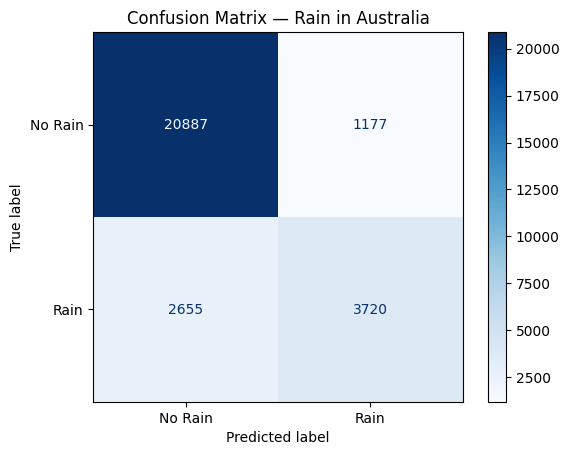

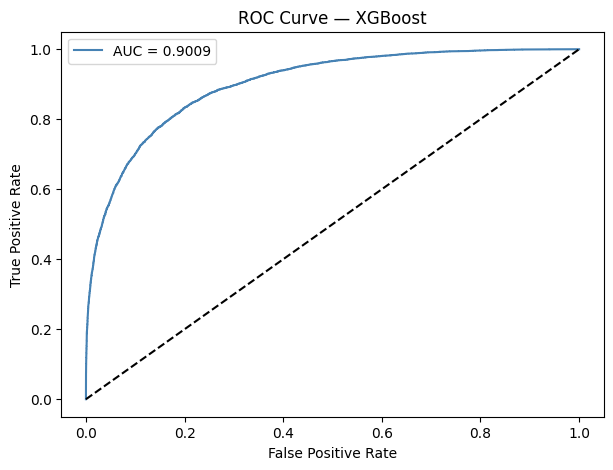

In [16]:
y_pred  = xgb_best.predict(X_test)
y_proba = xgb_best.predict_proba(X_test)[:, 1]

y_pred_train = xgb_best.predict(X_train_bal)

train_acc = accuracy_score(y_train_bal, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred)
train_auc = roc_auc_score(y_train_bal, xgb_best.predict_proba(X_train_bal)[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)

print("─" * 40)
print(f"{'Metric':<20} {'Train':>8} {'Test':>8}")
print("─" * 40)
print(f"{'Accuracy':<20} {train_acc:>8.4f} {test_acc:>8.4f}")
print(f"{'ROC-AUC':<20} {train_auc:>8.4f} {test_auc:>8.4f}")
print("─" * 40)

# ── Classification Report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_pred,
      target_names=['No Rain', 'Rain']))

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Rain', 'Rain'],
    cmap='Blues'
)
plt.title("Confusion Matrix — Rain in Australia")
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.show()

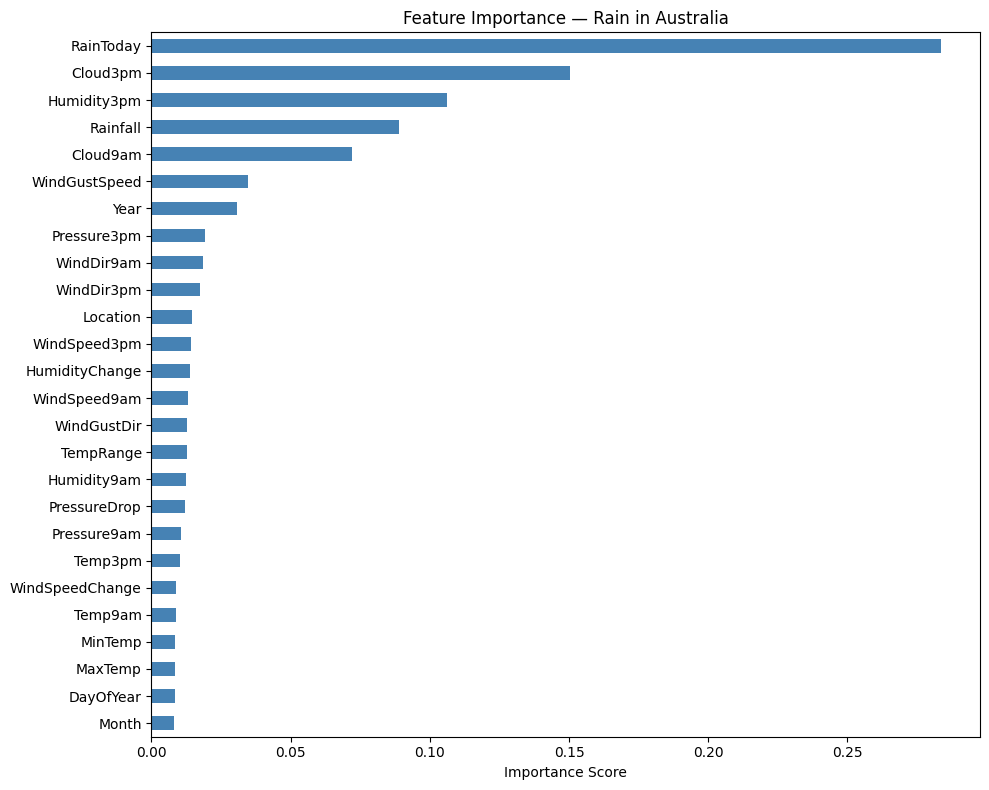

In [ ]:
importances = pd.Series(xgb_best.feature_importances_, index=X.columns)
importances.sort_values().plot(
    kind='barh', figsize=(10, 8), color='steelblue',
    title='Feature Importance — Rain in Australia'
)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()